In [1]:
import pandas as pd 
import numpy as np
import os 

In [37]:
# Before running this cell , make sure you run createFolder.py and you run this file in this dataCleaning folder, which is inside notebook folder
with open("dataFolder.txt",'r') as f:
    folder = f.read()


In [6]:
filePath  = os.path.join(folder,'07_scheme_performance.csv')

In [7]:
df = pd.read_csv(filePath)

In [8]:
df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


## validate all return values are numeric

In [9]:
df.dtypes

amfi_code               int64
scheme_name            object
fund_house             object
category               object
plan                   object
return_1yr_pct        float64
return_3yr_pct        float64
return_5yr_pct        float64
benchmark_3yr_pct     float64
alpha                 float64
beta                  float64
sharpe_ratio          float64
sortino_ratio         float64
std_dev_ann_pct       float64
max_drawdown_pct      float64
aum_crore               int64
expense_ratio_pct     float64
morningstar_rating      int64
risk_grade             object
dtype: object

In [10]:
import matplotlib.pyplot as plt

## check expense_ratio range (0.1% – 2.5%)

In [15]:
df[
    (df['expense_ratio_pct'] < 0.1) |
    (df['expense_ratio_pct'] > 2.5)
]

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade


## flag anomalies

In [21]:
df.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

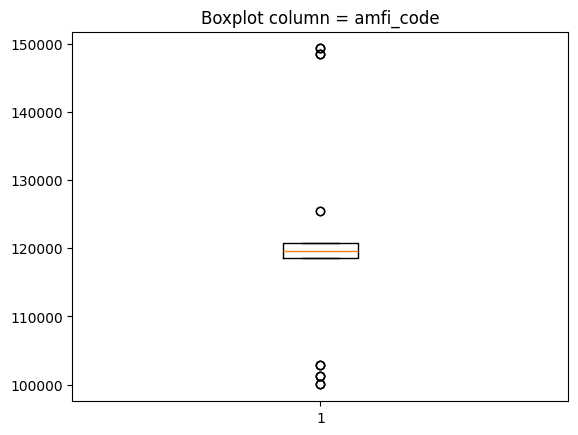

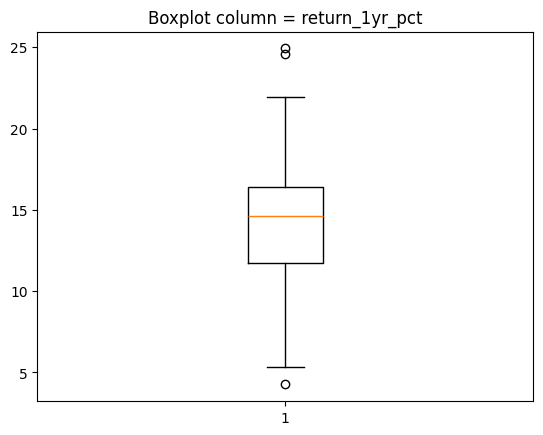

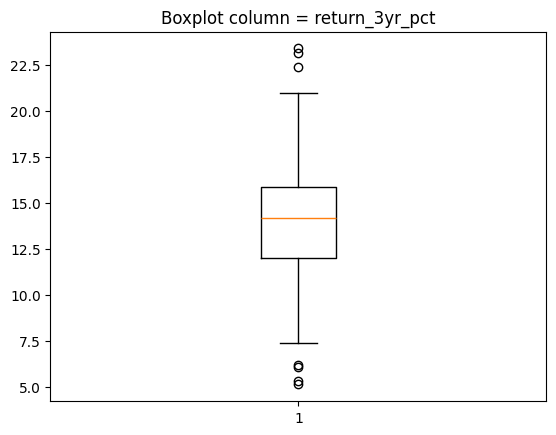

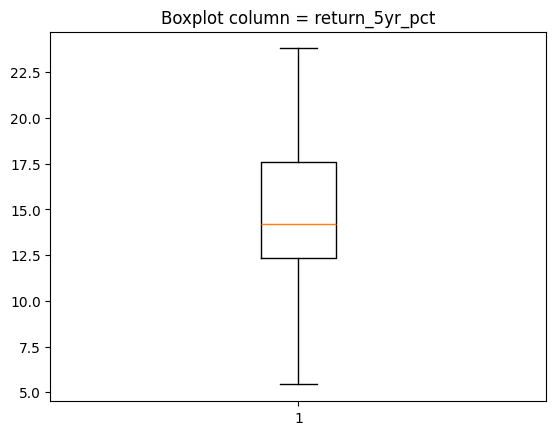

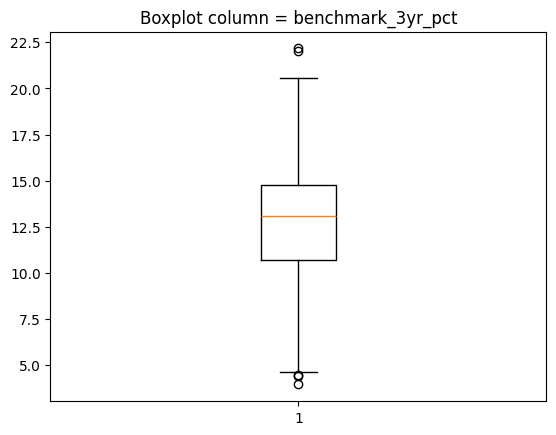

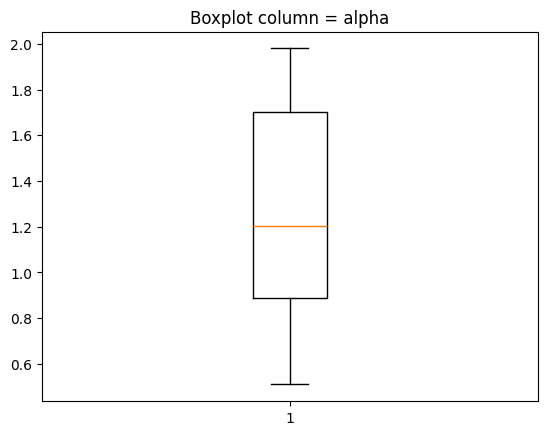

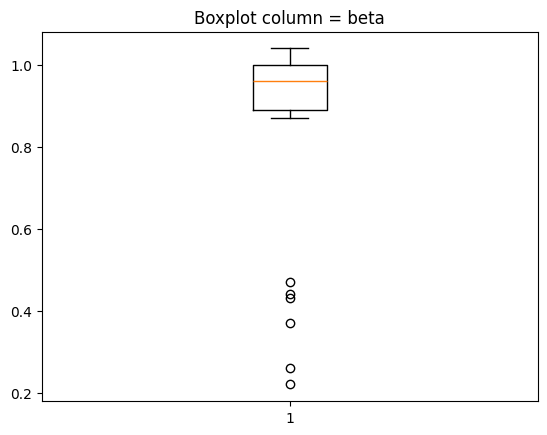

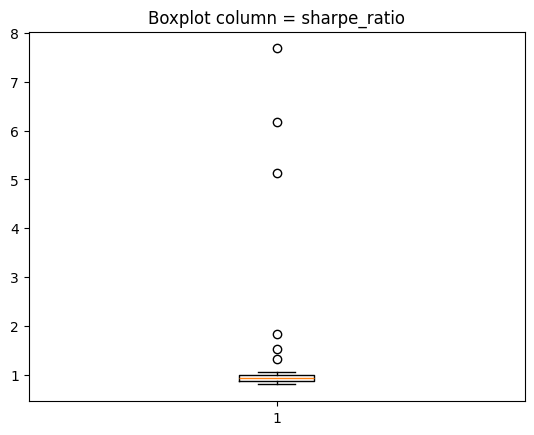

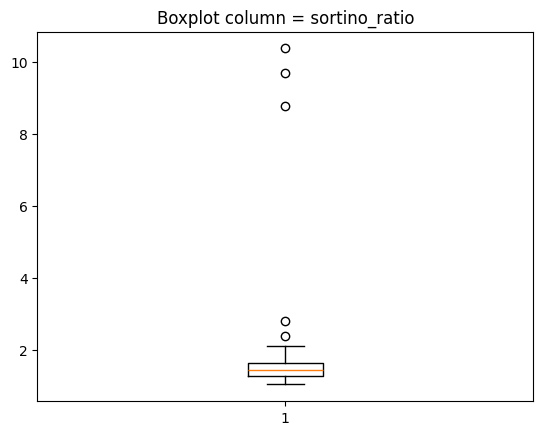

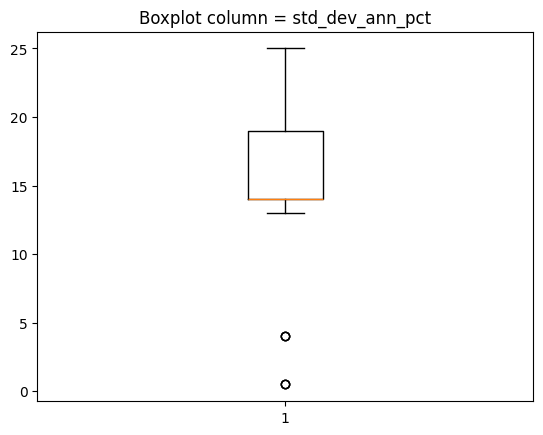

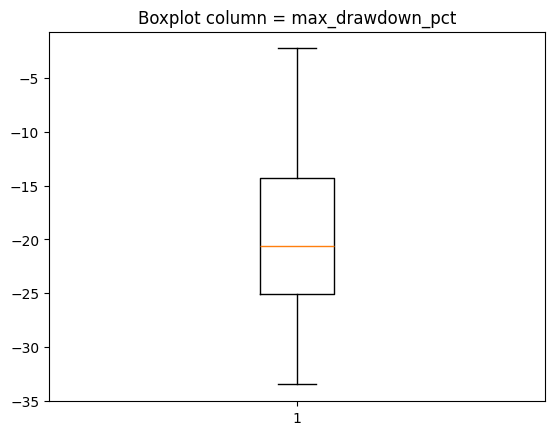

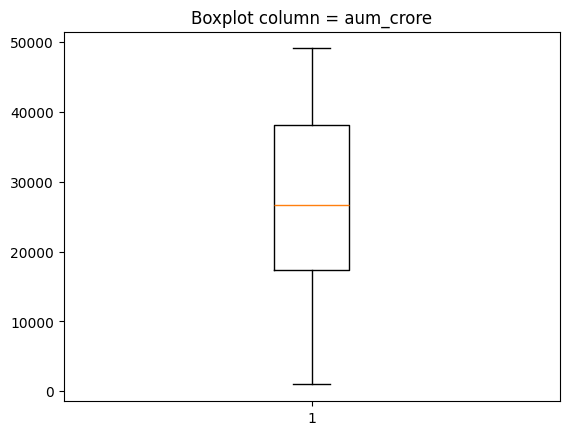

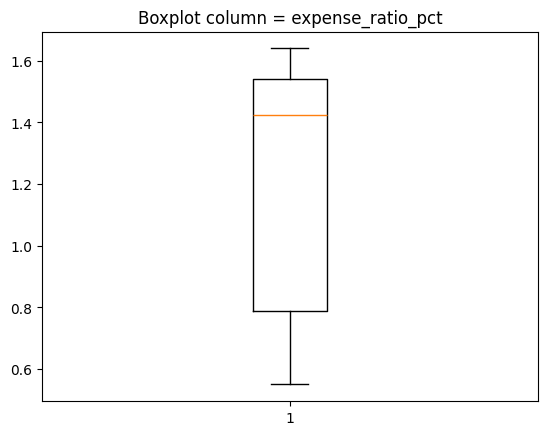

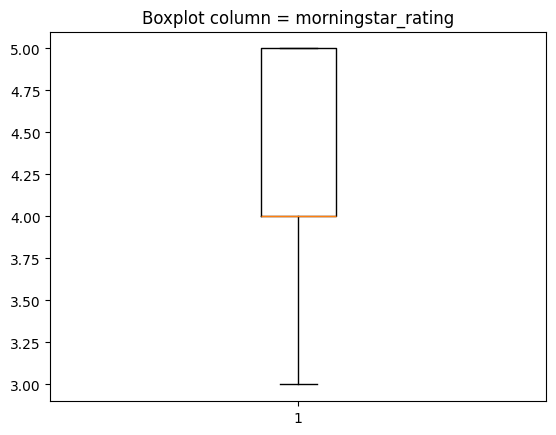

In [27]:
for i in df.describe().columns:
    plt.title(f"Boxplot column = {i}")
    plt.boxplot(df[i])
    plt.show()


In [32]:
return_cols = [
    'amfi_code',
    'return_1yr_pct',
    'return_3yr_pct',
    'benchmark_3yr_pct',
    'beta',
    'sharpe_ratio',
    'sortino_ratio',
    'std_dev_ann_pct'
]

In [34]:
for col in return_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[f"{col}_anomaly"] = (
        (df[col] < lower) |
        (df[col] > upper)
    )

In [35]:
df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,morningstar_rating,risk_grade,amfi_code_anomaly,return_1yr_pct_anomaly,return_3yr_pct_anomaly,benchmark_3yr_pct_anomaly,beta_anomaly,sharpe_ratio_anomaly,sortino_ratio_anomaly,std_dev_ann_pct_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,4,Moderate,False,False,False,False,False,False,False,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,3,Moderate,False,False,False,False,False,False,False,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,5,Very High,False,True,True,True,False,False,False,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,4,Very High,False,False,True,True,False,False,False,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,5,Low,False,False,True,True,True,True,False,True


In [36]:
df[df['beta_anomaly']==True]

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,morningstar_rating,risk_grade,amfi_code_anomaly,return_1yr_pct_anomaly,return_3yr_pct_anomaly,benchmark_3yr_pct_anomaly,beta_anomaly,sharpe_ratio_anomaly,sortino_ratio_anomaly,std_dev_ann_pct_anomaly
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,5,Low,False,False,True,True,True,True,False,True
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,3,Low,True,False,False,False,True,True,True,True
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,5,Low,False,False,False,False,True,True,True,True
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,...,4,Low,False,False,True,True,True,True,True,True
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,...,3,Low,False,True,True,False,True,True,True,True
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,...,5,Low,True,False,True,True,True,True,True,True


In [39]:
fol = os.path.dirname(folder)

In [41]:
savePath = os.path.join(fol,"processed")

In [43]:
df.to_csv(os.path.join(savePath,"c_scheme_performance.csv"),index=False)